In [1]:
import pandas as pd
from IPython.display import Image
from src.Instance import Instance
import utils
import pickle

import numpy as np
import matplotlib.pyplot as plt
import random
import time
from pathlib import Path
import dimod

import itertools
import multiprocessing

from gurobipy import GRB, Model, LinExpr, sys

from minorminer import find_embedding
from dwave.system import DWaveSampler, FixedEmbeddingComposite
import dwave.embedding

# Chapter 1
# From SAT to scaled BQM embedded 

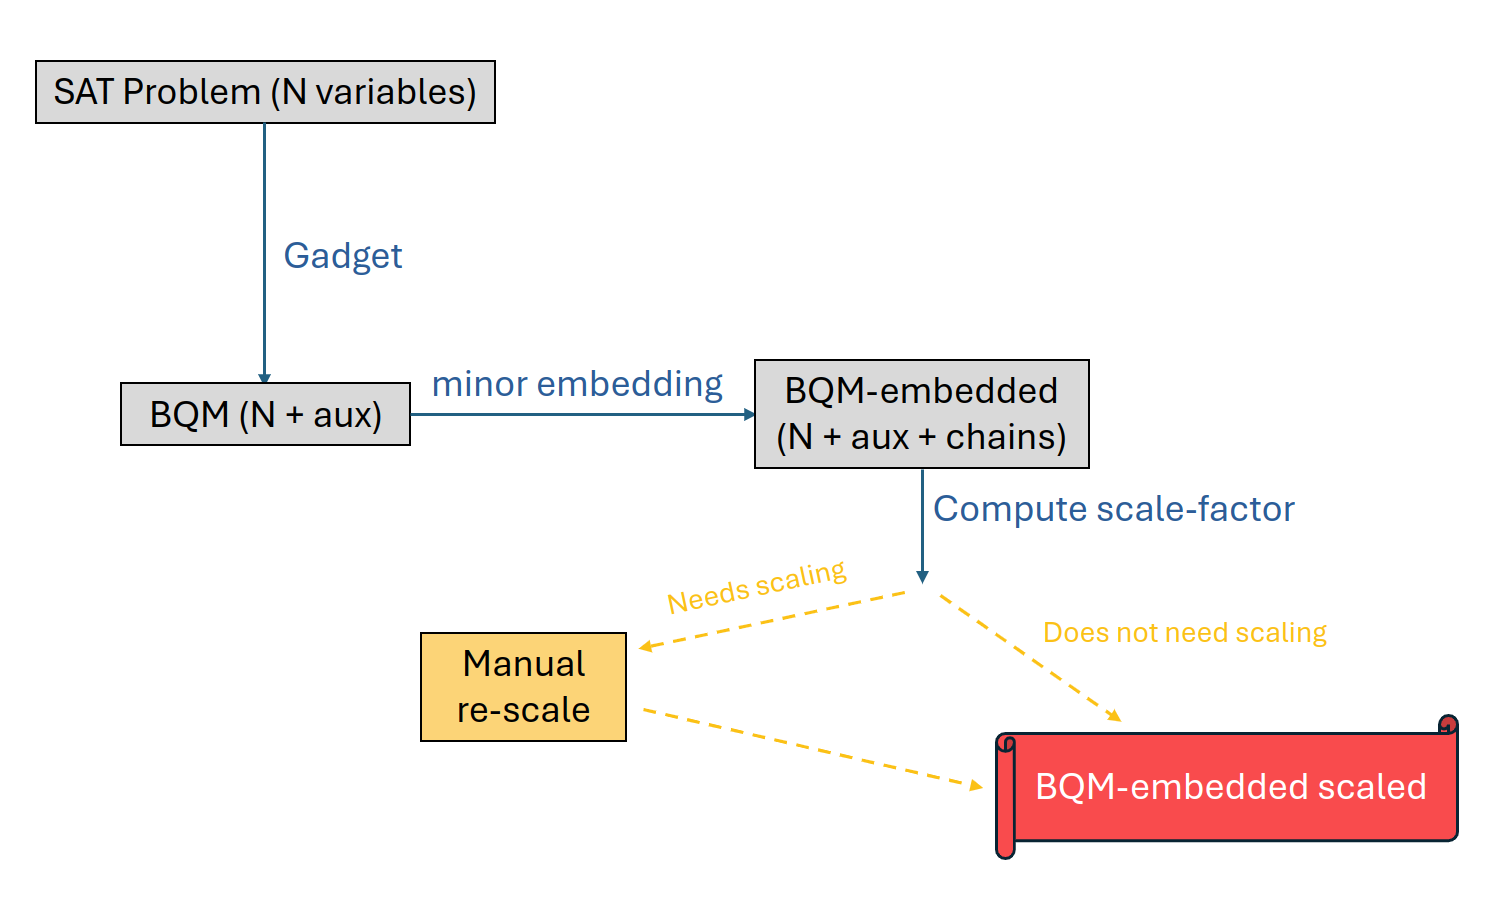

In [3]:
Image(filename='../figs/scaled_BQM_embedded_quest.png') 

## Generate SAT Problem

In [4]:
random.seed(901)
num_vars = 4

dir = "../exp/eBeyond/"
p_dir = Path(dir)
p_dir.mkdir(parents=True, exist_ok=True)

p = utils.generate_3sat(num_vars, ratio=4.2)
file_name = "p"+str(num_vars)+".cnf"
with open(p_dir / file_name,"w") as f:
    f.write(p)

In [5]:
file_path = dir + file_name

## Initialize instance

In [6]:
instance = Instance(file_path)

## Select Gadget

In [7]:
gadgets = [
    "Nuesslein1",
    "Nuesslein2",
    "CJ1",
    "CJ2"
]

## Compute BQM (N + aux)

In [8]:
for gadget in gadgets:
    getattr(instance, gadget).compute_bqm()
    print(f"BQM computed using {gadget}")

BQM computed using Nuesslein1
BQM computed using Nuesslein2
BQM computed using CJ1
BQM computed using CJ2


In [9]:
# instance.CJ1.bqm

## Brute force study of all solution space with energy landscape

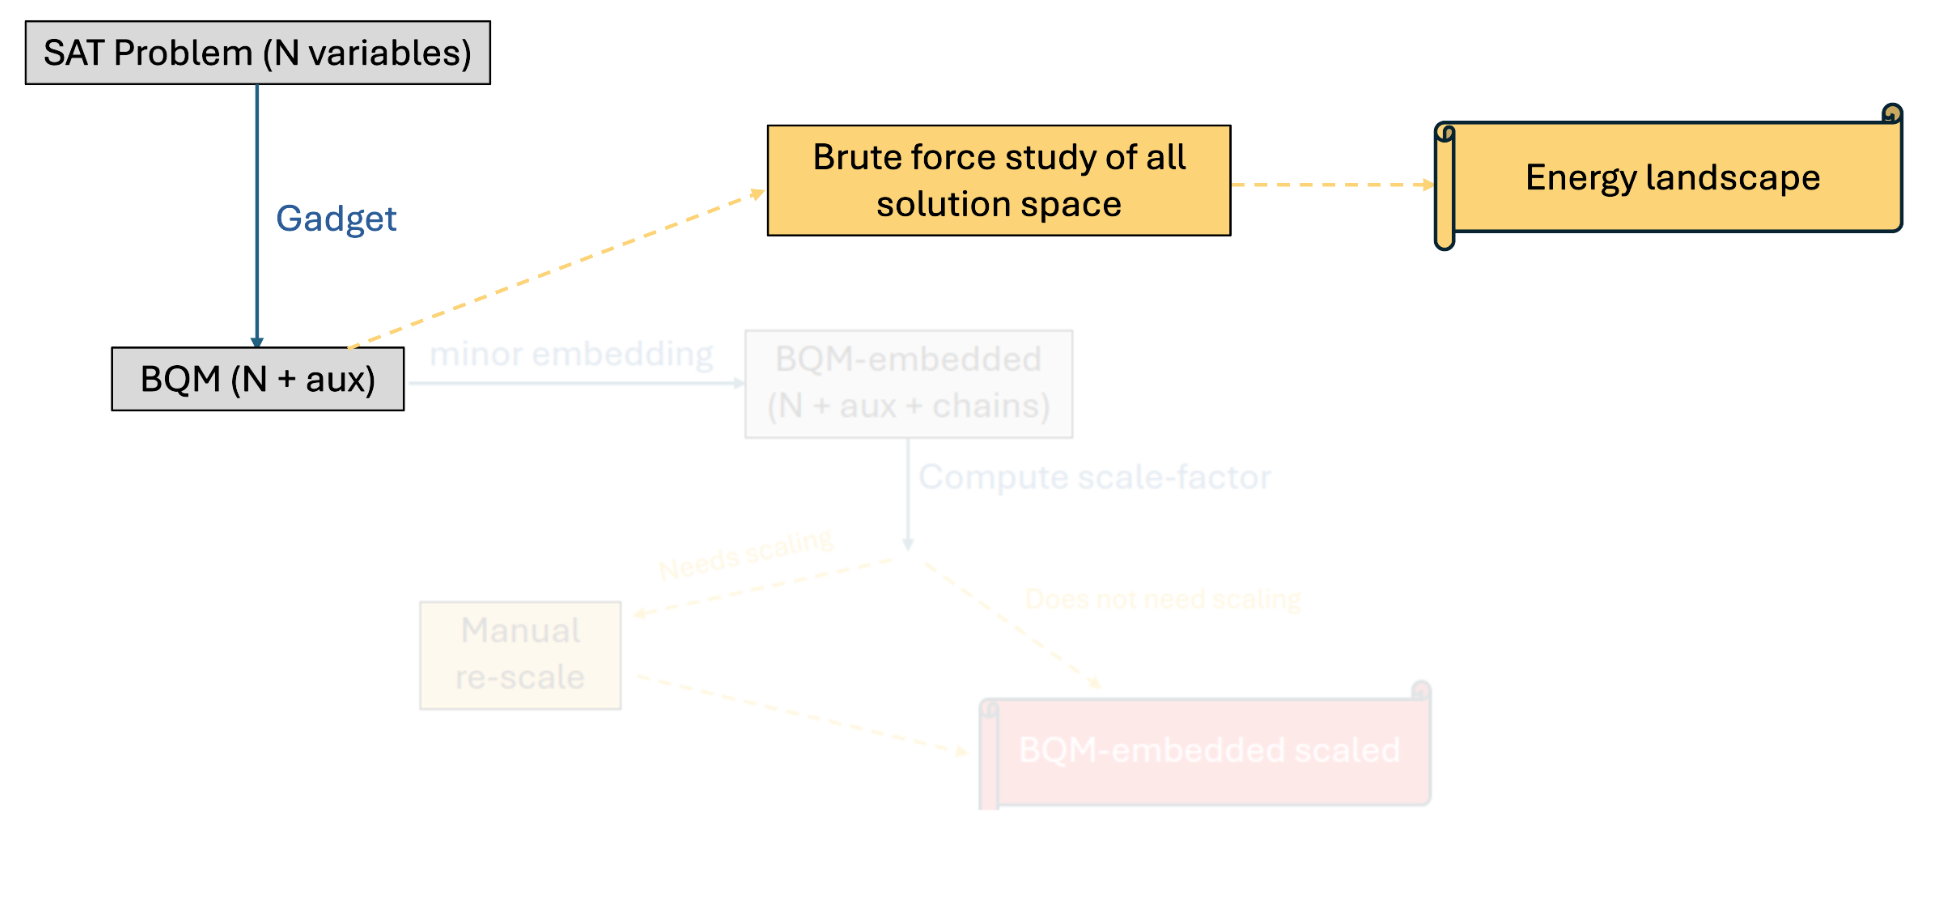

In [10]:
Image(filename='../figs/Solution_space_BQM_N_aux.png')

In [11]:
def energy_landscape_aux(possible_solutions, return_dict, bqm):
    all_solutions = []
    all_solutions_aux = []
    for solution in possible_solutions:
        energy = 0
        for (u, v), bias in bqm.quadratic.items():
            energy += bias * solution[u] * solution[v]
        for v, bias in bqm.linear.items():
            energy += bias * solution[v]
        all_solutions_aux.append((solution, energy))
    
    all_solutions.append(all_solutions_aux)
    return_dict[possible_solutions] = all_solutions

In [12]:
def compute_energy_landscape_in_parallel(gadget, parallel_batches, bqm):
    print(f"Using {gadget}...")
    possible_solutions = itertools.product([1, -1], repeat=len(bqm.variables))
    
    batches = {}
    batch_size = 2**len(bqm.variables) / parallel_batches
    assert batch_size.is_integer(), (f"The total number of solutions 2**{len(bqm.variables)} "
                                     f"is not divisible by the number of parallel batches ({parallel_batches}).")
    print(f"Number of solutions per batch: {int(batch_size)}")
    assert int(parallel_batches*batch_size) - int(2**len(bqm.variables)) == 0, "Batches not adding up"
    
    start_time = time.time()
    for i in range(parallel_batches):
        batches['batch'+str(i)] = itertools.islice(possible_solutions, int(i*batch_size), int((i+1)*batch_size))
        
    manager = multiprocessing.Manager()
    return_dict = manager.dict()
    jobs = []
    for key, value in batches.items():
        p = multiprocessing.Process(target=energy_landscape_aux, args=(value, return_dict, bqm))
        jobs.append(p)
        p.start()
    
    for proc in jobs:
        proc.join()
    end_time = time.time()
    print("TIME:", round(end_time - start_time, 1), "seconds")
    
    all_possible_solutions = []
    for lst in return_dict.values():
        all_possible_solutions.extend(lst[0])
    # print(len(all_possible_solutions))
    assert 2**len(bqm.variables) - len(all_possible_solutions) == 0, "Solutions missing"
    return all_possible_solutions

In [13]:
def plot_energy_landscape(gadget, all_possible_solutions, bqm, instance, save_png=False):
    logical_variables = sorted(bqm.variables)
    o_distr = {}
    for solution, energy in all_possible_solutions:
        assignment={logical_variables[j]:solution[j] if solution[j]!=-1 else 0 for j in range(len(solution))}
        o = int(utils.count_unsatisfied_clauses(assignment, instance.clauses))
        if o not in o_distr.keys():
            o_distr[o] = {energy: 1}
        else:
            if energy not in o_distr[o].keys():
                o_distr[o][energy] = 1
            else:
                o_distr[o][energy] += 1
                
    hist_distr = dict(sorted(o_distr.items()))    
    energy_values = [inner_dict_value for outer_dict_value in o_distr.values() for inner_dict_value in outer_dict_value.keys()]
    x_min = int(np.min(energy_values))
    x_max = int(np.max(energy_values))
    plt.figure(figsize=(20,4))
    plt.xticks(range(x_min,x_max+1,1), rotation=45)

    for i in range(len(list(hist_distr.keys())[:2])):
        plt.bar(list(hist_distr.values())[i].keys(), list(hist_distr.values())[i].values(), alpha=1-0.5*i, label=f'o{list(hist_distr.keys())[i]}')

    plt.title(f'{gadget}')
    plt.xlabel('Energy')
    plt.legend()
    if save_png is True:
        plt.savefig(f'../figs/{gadget}_p{instance.N}.png')
    plt.show()
 

In [14]:
brute_force_gadgets = [
    # "Nuesslein1",
    "Nuesslein2",
    "CJ1",
    "CJ2"
]
parallel_batches = 8

In [15]:
print("Total number of solutions:")
print("--------------------------")
for g in gadgets:
    print(f"2**{len(getattr(instance, g).bqm.variables)}={2**len(getattr(instance, g).bqm.variables)} for {g}")

Total number of solutions:
--------------------------
2**24=16777216 for Nuesslein1
2**20=1048576 for Nuesslein2
2**20=1048576 for CJ1
2**20=1048576 for CJ2


In [16]:
all_possible_solutions = {}
for gadget in brute_force_gadgets:
    all_possible_solutions[gadget] = compute_energy_landscape_in_parallel(gadget, parallel_batches, getattr(instance, gadget).bqm)

Using Nuesslein2...
Number of solutions per batch: 131072
TIME: 9.9 seconds
Using CJ1...
Number of solutions per batch: 131072
TIME: 8.9 seconds
Using CJ2...
Number of solutions per batch: 131072
TIME: 8.5 seconds


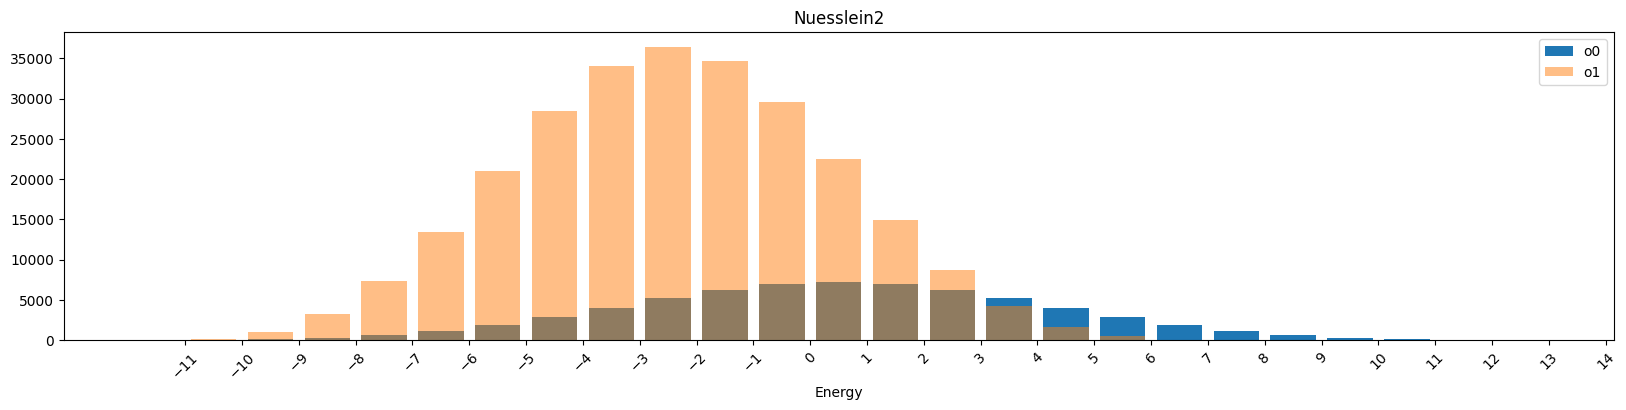

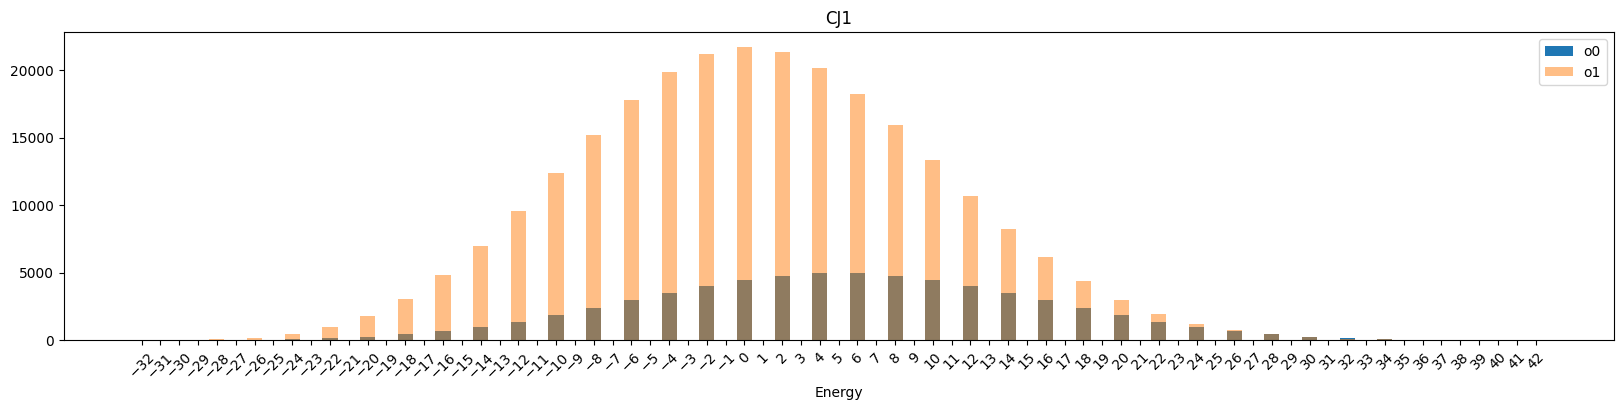

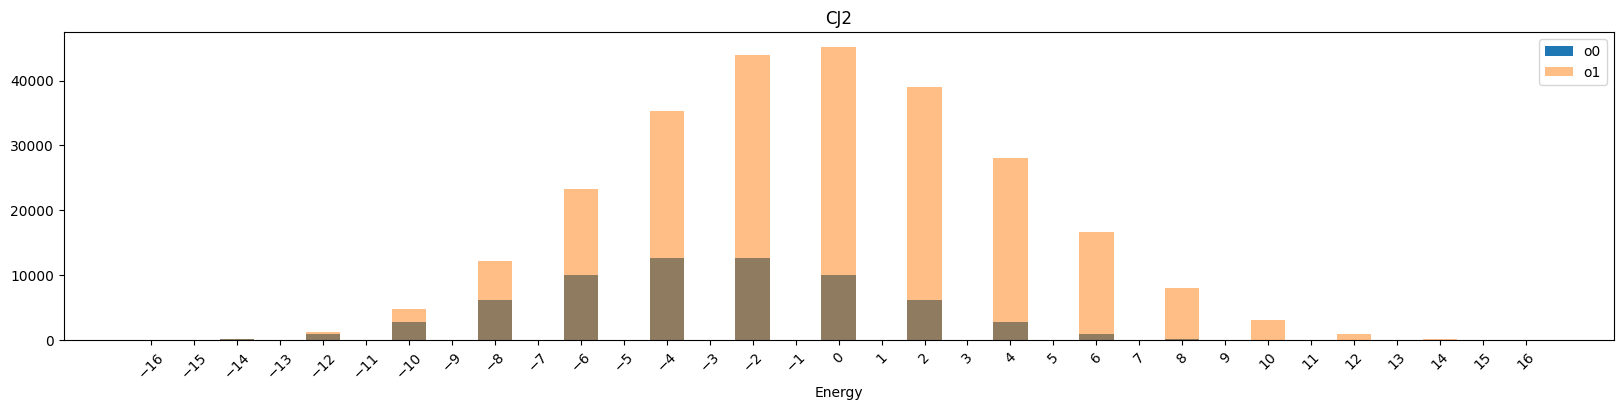

In [17]:
for gadget in brute_force_gadgets:
    plot_energy_landscape(gadget, all_possible_solutions[gadget], getattr(instance, gadget).bqm, instance, save_png=False)

In [18]:
for gadget in brute_force_gadgets:
    getattr(instance, gadget).all_solution_space['bqm'] = all_possible_solutions[gadget]

## Compute BQM embedded (N + aux + chains)

In [30]:
token = "Your token"

In [20]:
for gadget in gadgets:
    getattr(instance, gadget).compute_bqm_embedded(token)

In [21]:
# instance.CJ1.bqm_embedded

## Compute scaling factor and scaled BQM embedded

In [22]:
for gadget in gadgets:
    getattr(instance, gadget).compute_scaled_bqm_embedded(token)

In [23]:
# print(instance.CJ1.bqm_embedded['bqm_embedded'])
print(instance.CJ1.scale_factor)
# print(instance.CJ1.scaled_bqm_embedded['scaled_bqm_embedded'])

1.3690996128843216


# Chapter 2
# From scaled BQM embedded to Solutions

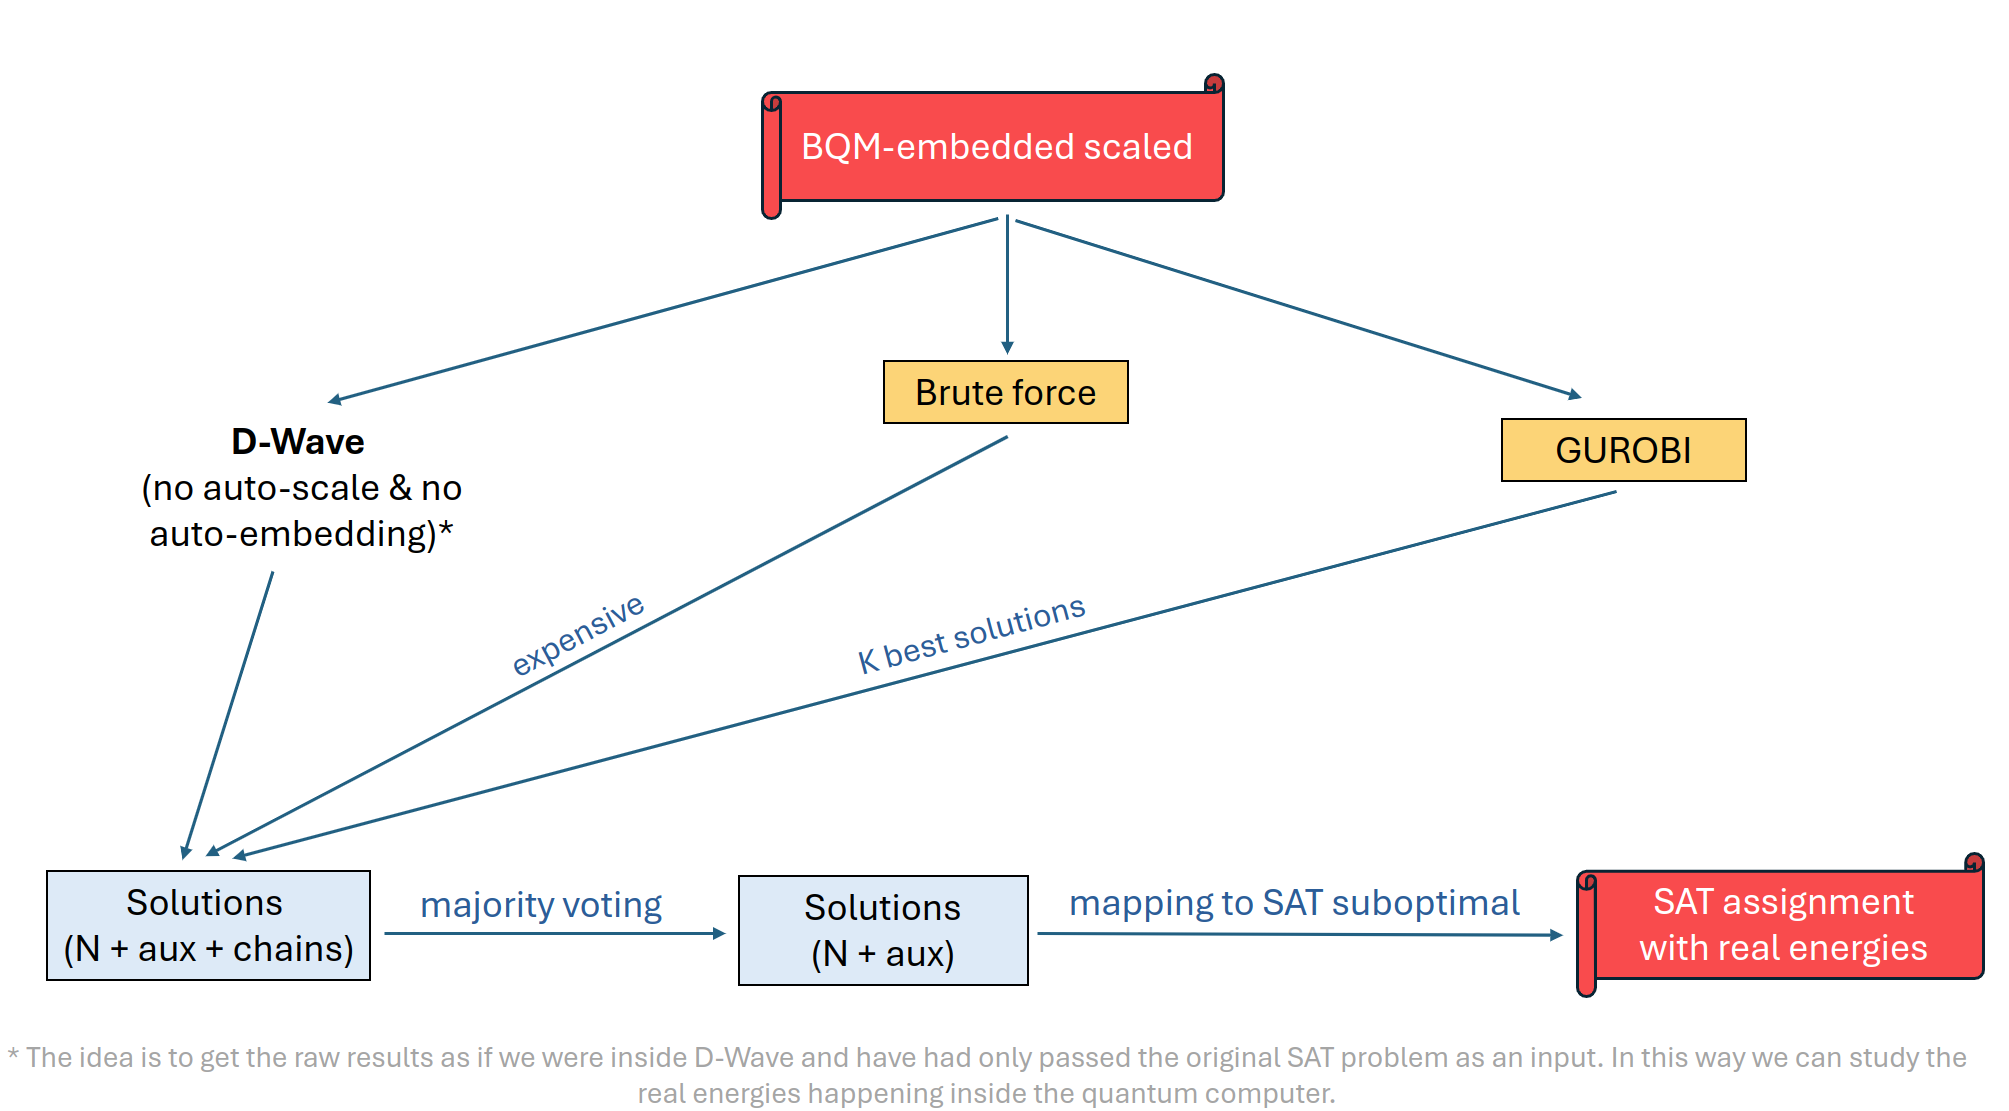

In [24]:
Image(filename='../figs/From_scaled_BQM_embedded_to_solutions.png') 

## Get D-Wave solutions (no auto-scale & no auto-embedding)

In [25]:
secure_question = input("Do you really want to use D-Wave? (y/n)")
if secure_question in ["Yes", "Y", "y", "yes"]:
    for gadget in gadgets:
        getattr(instance, gadget).solve_dwave_from_scaled_bqm_embedded(token, num_reads=100, annealing_time=100)

In [26]:
# instance.CJ1.response_dwave_from_scaled_bqm_embedded.samples

## GUROBI: get K best solutions

In [27]:
def solve_gurobi(scaled_bqm_embedded, num_solutions=100):
    qubits = list(scaled_bqm_embedded.variables)
    q_names = list(map(str,scaled_bqm_embedded.variables))

    model = Model(name = 'linear program')
    q=model.addVars(qubits, name=q_names, vtype = GRB.INTEGER, lb=-1, ub=1)
   
    for qub in qubits:
        model.addConstr(q[qub]*q[qub] == 1, name='non_zero')

    obj_fn = LinExpr()
    for (u, v), bias in scaled_bqm_embedded.quadratic.items():
        obj_fn += bias * q[u] * q[v]
    for v, bias in scaled_bqm_embedded.linear.items():
        obj_fn += bias * q[v]
    model.setObjective(obj_fn, GRB.MINIMIZE)

    solutions = []
    model.setParam(GRB.Param.PoolSolutions, num_solutions)
    model.setParam(GRB.Param.PoolSearchMode, 2)
    #model.setParam(GRB.Param.PoolGap, 100)
    model.setParam(GRB.Param.Cutoff, GRB.INFINITY)
    model.optimize()
   
    nSolutions = model.SolCount
    # print(f"Number of solutions found: {nSolutions}")
   
    for e in range(nSolutions):
        model.setParam(GRB.Param.SolutionNumber, e)
   
        # Status checking
        status = model.Status
        if status in (GRB.INF_OR_UNBD, GRB.INFEASIBLE, GRB.UNBOUNDED):
            print("The model cannot be solved because it is infeasible or unbounded")
            sys.exit(1)
        if status != GRB.OPTIMAL:
            print(f"Optimization was stopped with status {status}")
            sys.exit(1)
   
        energy = model.PoolObjVal
   
        assignment = {}
        for v in model.getVars():
            if round(v.Xn)==1:
                assignment[int(v.varName)] = 1
            else:
                assignment[int(v.varName)] = -1
   
        solutions.append([list(assignment.values()), energy])

    return solutions

In [28]:
# for gadget in gadgets:
#     gurobi_solutions = solve_gurobi(getattr(instance, gadget).scaled_bqm_embedded['scaled_bqm_embedded'], num_solutions=100)
#     getattr(instance, gadget).gurobi_solutions['scaled_bqm_embedded'] = gurobi_solutions

## Save pickle file

In [29]:
with open(file_path+'.pkl', 'wb') as f:
    pickle.dump(instance, f)